In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
625,626,0,1,"Sutton, Mr. Frederick",male,61.0,0,0,36963,32.3208,D50,S
173,174,0,3,"Sivola, Mr. Antti Wilhelm",male,21.0,0,0,STON/O 2. 3101280,7.9250,NaN,S
130,131,0,3,"Drazenoic, Mr. Jozef",male,33.0,0,0,349241,7.8958,NaN,C
736,737,0,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.3750,NaN,S
399,400,1,2,"Trout, Mrs. William H (Jessie L)",female,28.0,0,0,240929,12.6500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.drop(columns=["PassengerId","Name","Ticket"],inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [8]:
print("Duplicates: ", df.duplicated().sum())

Duplicates:  107


In [9]:
df = df.drop_duplicates()

In [10]:
print("Duplicates: ", df.duplicated().sum())

Duplicates:  0


In [11]:
print(df.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age         106
SibSp         0
Parch         0
Fare          0
Cabin       581
Embarked      2
dtype: int64


In [12]:
df["Age"].fillna(df["Age"].median(),inplace= True)

C:\Users\TroubleMaker\AppData\Local\Temp\ipykernel_3316\2526198580.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace= True)


In [13]:
df.drop(columns=["Cabin"],inplace=True)

In [14]:
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64


In [15]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

C:\Users\TroubleMaker\AppData\Local\Temp\ipykernel_3316\548196730.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)


In [16]:
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [17]:
import matplotlib.pyplot as plt

<Axes: >

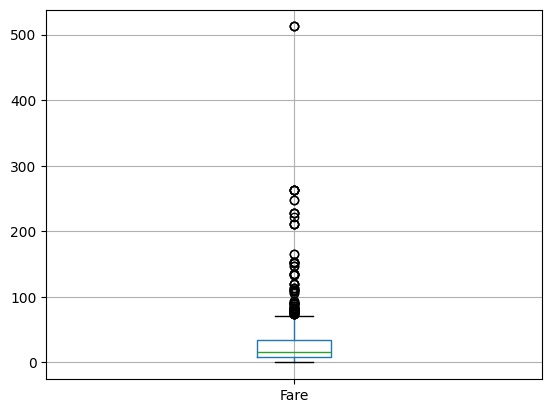

In [18]:
df.boxplot(column="Fare")

In [19]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df["Fare"]<(Q1-1.5*IQR)) | 
         (df["Fare"]>(Q3+1.5*IQR)))]

print("Shape after outlier removal: ", df.shape)

Shape after outlier removal:  (682, 8)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 682 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  682 non-null    int64  
 1   Pclass    682 non-null    int64  
 2   Sex       682 non-null    object 
 3   Age       682 non-null    float64
 4   SibSp     682 non-null    int64  
 5   Parch     682 non-null    int64  
 6   Fare      682 non-null    float64
 7   Embarked  682 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 48.0+ KB


In [21]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

In [25]:
le = LabelEncoder()
df["Survived"] = le.fit_transform(df["Survived"])

ohe_sex = OneHotEncoder(sparse_output=False,drop="first")
encoded_sex = ohe_sex.fit_transform(df[["Sex"]])
encoded_sex_df = pd.DataFrame(encoded_sex,
                             columns=ohe_sex.get_feature_names_out(["Sex"]),
                             index=df.index)

df = pd.concat([df,encoded_sex_df],axis=1)
df.drop(columns=["Sex"],inplace=True)

oe = OrdinalEncoder(categories=[[1,2,3]])
df[["Pclass"]] = oe.fit_transform(df[["Pclass"]])

In [26]:
print(df.head())
print(df.shape)
print(df.info())

   Survived  Pclass   Age  SibSp  Parch     Fare Embarked  Sex_male
0         0     2.0  22.0      1      0   7.2500        S       1.0
1         1     0.0  38.0      1      0  71.2833        C       0.0
2         1     2.0  26.0      0      0   7.9250        S       0.0
3         1     0.0  35.0      1      0  53.1000        S       0.0
4         0     2.0  35.0      0      0   8.0500        S       1.0
(682, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 682 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  682 non-null    int64  
 1   Pclass    682 non-null    float64
 2   Age       682 non-null    float64
 3   SibSp     682 non-null    int64  
 4   Parch     682 non-null    int64  
 5   Fare      682 non-null    float64
 6   Embarked  682 non-null    object 
 7   Sex_male  682 non-null    float64
dtypes: float64(4), int64(3), object(1)
memory usage: 48.0+ KB
None


In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [28]:
minmax = MinMaxScaler()
df[["Age"]] = minmax.fit_transform(df[["Age"]])

In [29]:
robust = RobustScaler()
df[["Fare"]] = robust.fit_transform(df[["Fare"]])

In [31]:
minmax2 = MinMaxScaler()
df[["SibSp"]] = minmax2.fit_transform(df[["SibSp"]])

In [32]:
minmax3 = MinMaxScaler()
df[["Parch"]] = minmax2.fit_transform(df[["Parch"]])

In [33]:
print(df.head())

   Survived  Pclass       Age  SibSp  Parch      Fare Embarked  Sex_male
0         0     2.0  0.271174  0.125    0.0 -0.308242        S       1.0
1         1     0.0  0.472229  0.125    0.0  3.124406        C       0.0
2         1     2.0  0.321438  0.000    0.0 -0.272057        S       0.0
3         1     0.0  0.434531  0.125    0.0  2.149650        S       0.0
4         0     2.0  0.434531  0.000    0.0 -0.265356        S       1.0


In [34]:
import matplotlib.pyplot as plt

# Scalers use karke original values wapas lo
age_orig = minmax.inverse_transform(df[['Age']])
fare_orig = robust.inverse_transform(df[['Fare']])
sibsp_orig = minmax2.inverse_transform(df[['SibSp']])
parch_orig = minmax3.inverse_transform(df[['Parch']])

# ============================================
# Age — MinMax
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Age — MinMax Scaling', fontsize=14, fontweight='bold')
axes[0].hist(age_orig, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Age — Before Scaling')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[1].hist(df['Age'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('Age — After MinMax (0 to 1)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# ============================================
# Fare — Robust
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fare — Robust Scaling', fontsize=14, fontweight='bold')
axes[0].hist(fare_orig, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Fare — Before Scaling')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[1].hist(df['Fare'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('Fare — After Robust')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# ============================================
# SibSp — MinMax
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SibSp — MinMax Scaling', fontsize=14, fontweight='bold')
axes[0].hist(sibsp_orig, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('SibSp — Before Scaling')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[1].hist(df['SibSp'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('SibSp — After MinMax (0 to 1)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# ============================================
# Parch — MinMax
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Parch — MinMax Scaling', fontsize=14, fontweight='bold')
axes[0].hist(parch_orig, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Parch — Before Scaling')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[1].hist(df['Parch'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('Parch — After MinMax (0 to 1)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

NotFittedError: This MinMaxScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.